In [1]:
import numpy as np

# 第一階段變換
def rescale_x(x):
    return 0.2696 * x + 0.1818

# 第二階段歸一化 (選擇性)
def normalize_x(x_new):
    return (x_new + 0.088) / (0.504 + 0.088)

# 舊的 x 軸數據
x_old = np.linspace(-1, 1.2, 100)  # 假設你有 100 個點

# 變換到新座標
x_new = rescale_x(x_old)

# 如果想歸一化到 [0,1]
x_normalized = normalize_x(x_new)

print(x_new[:5])  # 查看變換後的前5個點
print(x_normalized[:5])  # 查看歸一化後的前5個點


[-0.0878     -0.08180889 -0.07581778 -0.06982667 -0.06383556]
[0.00033784 0.01045796 0.02057808 0.0306982  0.04081832]


In [3]:
normalize_x(-0.7)

-1.0337837837837838

In [22]:
import Labber
import matplotlib.pyplot as plt
np.bool=bool
np.float=float
d1 = r'C:\Users\SQC\Desktop\tprocv2_scrip\data\2025\02\Data_0221\quniy flux spec_3.hdf5'
d1 = Labber.LogFile(d1)
x, y = d1.getTraceXY()
data = d1.getData()
step=len(data)
step

d1flux = d1.getStepChannels()[1]['values']

In [13]:
z1 = []
for i in range(step):
    x, y = d1.getTraceXY(entry=i)
    z1.append(x[np.argmin(np.abs(y))])

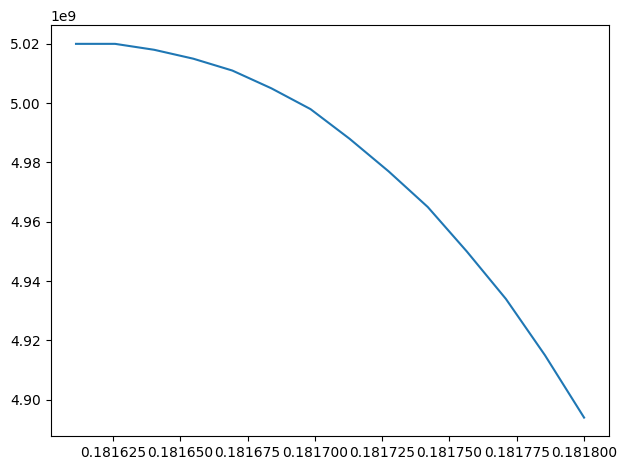

In [24]:
plt.plot(rescale_x(d1flux),z1)
plt.tight_layout()

In [30]:
data2=r'C:\Users\SQC\Desktop\tprocv2_scrip\data\2025\02\Data_0222\quniy flux spec_5.hdf5'
d2 = Labber.LogFile(data2)
x, y = d2.getTraceXY()
data2 = d2.getData()
step2=len(data2)


d2flux = d2.getStepChannels()[1]['values']

In [47]:
z3 = []
def compute_mean_std(x):
    mean = np.mean(x)
    std = np.std(x, ddof=1)  # 使用 ddof=1 計算不偏標準差（樣本標準差）
    return mean, std

def find_extreme_outlier(x, threshold=3):
    """
    找出超過 mean ± threshold * std 的最大或最小離群值索引
    :param x: 輸入數據（NumPy array）
    :param threshold: 判斷離群值的標準差倍數，預設 1.5
    :return: 最極端的離群值索引
    """
    mean = np.mean(x)
    std = np.std(x, ddof=1)  # 樣本標準差
    lower_bound = mean - threshold * std
    upper_bound = mean + threshold * std

    # 找出超出範圍的數值及其索引
    outlier_indices = np.where((x < lower_bound) | (x > upper_bound))[0]
    
    if len(outlier_indices) == 0:
        return None  # 沒有離群值
    
    # 取最極端的離群值
    extreme_index = outlier_indices[np.argmax(np.abs(x[outlier_indices] - mean))]
    
    return extreme_index
for i in range(step2):
    x, y = d2.getTraceXY(entry=i)
    mean, std = compute_mean_std(np.abs(y))
    idx = find_extreme_outlier(np.abs(y))
    z3.append(x[idx])


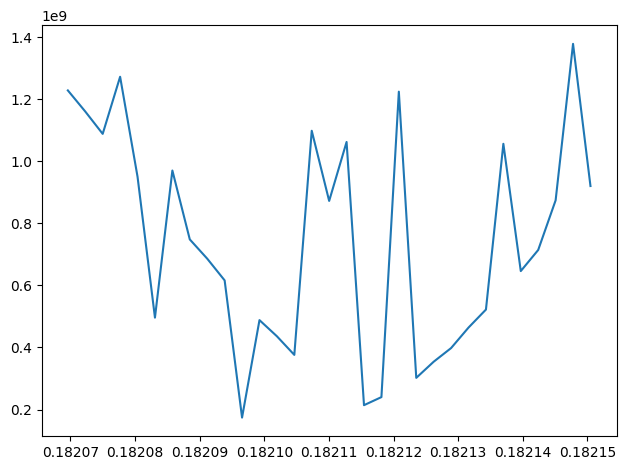

In [48]:

plt.plot(rescale_x(d2flux),z3)
plt.tight_layout()